# 🚗 Used Car Price Prediction

## Regression Analysis & Machine Learning

This section extends the previous Exploratory Data Analysis project into a supervised machine learning problem.

The objective is to build regression models capable of predicting used car selling prices.

The workflow follows:

**Data Understanding → EDA → Train/Test Split → Preprocessing → Multicollinearity → Model Training → Evaluation → Model Comparison → Final Decision**

Special attention is given to regularization, feature scaling, multicollinearity, and data leakage prevention.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor

## 1. Data Understanding

The cleaned dataset from the previous EDA stage is loaded for the regression analysis.

The target variable is `selling_price`.

The dataset has already gone through the main data cleaning and feature engineering steps from Version 1.

In [3]:
df = pd.read_csv("cleaned_car_data.csv")

print("Shape:", df.shape)

display(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (3926, 11)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age,price_per_km,brand
0,Maruti 800 AC,2007.0,350000.0,70000.0,Petrol,Individual,Manual,First Owner,19.0,5.000000,Maruti
1,Maruti Wagon R LXI Minor,2014.0,135000.0,50000.0,Petrol,Individual,Manual,First Owner,12.0,2.700000,Maruti
2,Hyundai Verna 1.6 SX,2012.0,600000.0,100000.0,Diesel,Individual,Manual,First Owner,14.0,6.000000,Hyundai
3,Datsun RediGO T Option,2017.0,250000.0,46000.0,Petrol,Individual,Manual,First Owner,9.0,5.434783,Datsun
4,Honda Amaze VX i-DTEC,2014.0,450000.0,141000.0,Diesel,Individual,Manual,Second Owner,12.0,3.191489,Honda



Data Types:
name                 str
year             float64
selling_price    float64
km_driven        float64
fuel                 str
seller_type          str
transmission         str
owner                str
car_age          float64
price_per_km     float64
brand                str
dtype: object

Missing Values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
car_age          0
price_per_km     0
brand            0
dtype: int64

Duplicate Rows: 0


## 2. Identify Numerical and Categorical Features

The dataset contains both numerical and categorical variables.

For the regression models, `selling_price` is the target variable.

The `name` column is excluded from modeling because it has very high cardinality and contains individual vehicle model names.

The `brand` feature created during EDA is used instead because it provides a more general representation of the vehicle manufacturer.

In [4]:
target = "selling_price"

X = df.drop(columns=[target])
y = df[target]

# Remove high-cardinality and target-derived features
X = X.drop(columns=["name", "price_per_km"], errors="ignore")

# Remove year because car_age contains the same information
X = X.drop(columns=["year"], errors="ignore")

numeric_features = [
    "km_driven",
    "car_age"
]

categorical_features = [
    "fuel",
    "seller_type",
    "transmission",
    "owner",
    "brand"
]

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['km_driven', 'car_age']

Categorical Features:
['fuel', 'seller_type', 'transmission', 'owner', 'brand']


## 3. Train/Test Split

The dataset is split into training and testing sets before fitting any preprocessing steps.

This is important for preventing Data Leakage.

The test set must remain completely unseen during preprocessing and model training.

The training set will be used to learn imputation values, scaling parameters, and categorical encoding.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (3140, 7)
Testing Set: (786, 7)


## 4. Multicollinearity Analysis

Multicollinearity occurs when two or more predictor variables contain highly similar information.

A correlation matrix is used as a first step to identify strong relationships between numerical predictors.

The target variable is excluded because multicollinearity concerns relationships among predictors.

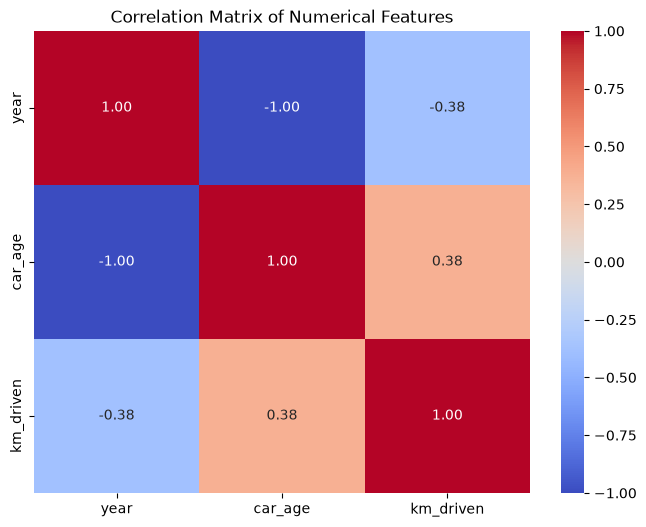

In [6]:
correlation_features = ["year","car_age","km_driven"]

correlation_matrix = df[correlation_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix of Numerical Features")
plt.show()

### Variance Inflation Factor (VIF)

VIF measures how strongly a numerical predictor can be explained by the other predictors.

A high VIF indicates potential multicollinearity.

In this dataset, `year` and `car_age` are mathematically related because:

`car_age = 2026 - year`

Therefore, we expect very high VIF values for these two variables.

To avoid redundant information, `year` is excluded from the machine learning features and `car_age` is retained.

In [7]:
vif_data = df[["year","car_age","km_driven"]].dropna()

vif_results = pd.DataFrame()

vif_results["Feature"] = vif_data.columns

vif_results["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]

vif_results

,Feature,VIF
0,year,10.975312
1,car_age,12.734949
2,km_driven,1.167995


## 5. Preprocessing

Different types of preprocessing are required for numerical and categorical variables.

Numerical features are standardized for linear models using `StandardScaler`.

Categorical features are converted into numerical form using `OneHotEncoder`.

All preprocessing is placed inside a `ColumnTransformer` and `Pipeline`.

This ensures that preprocessing parameters are learned only from the training data, preventing Data Leakage.

In [8]:
numeric_transformer_scaled = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])

numeric_transformer_unscaled = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])

categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),("encoder",OneHotEncoder(handle_unknown="ignore",sparse_output=False))])

preprocessor_scaled = ColumnTransformer(transformers=[("num", numeric_transformer_scaled, numeric_features),("cat", categorical_transformer, categorical_features)])

preprocessor_unscaled = ColumnTransformer(transformers=[("num", numeric_transformer_unscaled, numeric_features),("cat", categorical_transformer, categorical_features)])

## 6. Model Training

Several regression models are trained and compared.

The models include:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor

Linear, Ridge, and Lasso models use standardized numerical features.

Tree-based models do not require feature scaling, so their numerical features are passed without scaling.

All models use the same train/test split to ensure a fair comparison.

In [9]:
models = {"Linear Regression": Pipeline(steps=[("preprocessor", preprocessor_scaled),("model", LinearRegression())]),
          "Ridge Regression": Pipeline(steps=[("preprocessor", preprocessor_scaled),("model", Ridge(alpha=1.0))]),
          "Lasso Regression": Pipeline(steps=[("preprocessor", preprocessor_scaled),("model", Lasso(alpha=1.0, max_iter=10000))]),
          "Decision Tree": Pipeline(steps=[("preprocessor", preprocessor_unscaled),("model", DecisionTreeRegressor(max_depth=10,random_state=42))]),
          "Random Forest": Pipeline(steps=[("preprocessor", preprocessor_unscaled),("model", RandomForestRegressor(n_estimators=200,random_state=42,n_jobs=-1))]),
          "Gradient Boosting": Pipeline(steps=[("preprocessor", preprocessor_unscaled),("model", GradientBoostingRegressor(n_estimators=200,learning_rate=0.05,max_depth=3,random_state=42))])
          }

## 7. Model Evaluation

The models are evaluated using three regression metrics:

### MAE — Mean Absolute Error

Measures the average absolute difference between actual and predicted prices.

Lower MAE is better.

### RMSE — Root Mean Squared Error

Measures prediction error while giving greater weight to large errors.

Lower RMSE is better.

### R-squared

Measures how much of the variation in the target variable is explained by the model.

Higher R-squared is better.

In [10]:
results = []

trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name,"MAE": mae,"RMSE": rmse,"R-squared": r2})

    trained_models[name] = model

results_df = pd.DataFrame(results)

results_df = results_df.sort_values("RMSE").reset_index(drop=True)

results_df

,Model,MAE,RMSE,R-squared
0,Gradient Boosting,169401.890324,317827.436874,0.637818
1,Random Forest,164235.523356,323747.556863,0.624200
2,Decision Tree,176557.086363,358048.727217,0.540349
3,Ridge Regression,194577.006326,364881.193596,0.522639
4,Linear Regression,194967.267312,366090.098276,0.519471
5,Lasso Regression,194974.900244,366094.477159,0.519460


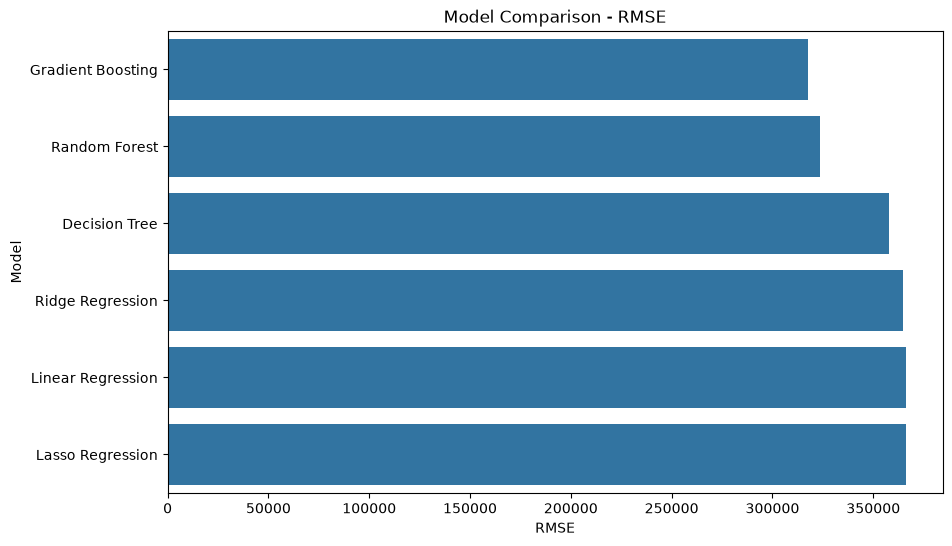

In [11]:
plt.figure(figsize=(10, 6))

sns.barplot(data=results_df,x="RMSE",y="Model")

plt.title("Model Comparison - RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.show()

In [12]:
best_model = results_df.iloc[0]

print("Best Model:", best_model["Model"])
print("MAE:", round(best_model["MAE"], 2))
print("RMSE:", round(best_model["RMSE"], 2))
print("R-squared:", round(best_model["R-squared"], 4))

Best Model: Gradient Boosting
MAE: 169401.89
RMSE: 317827.44
R-squared: 0.6378


In [13]:
linear_rmse = results_df.loc[results_df["Model"] == "Linear Regression","RMSE"].iloc[0]

ridge_rmse = results_df.loc[results_df["Model"] == "Ridge Regression","RMSE"].iloc[0]

lasso_rmse = results_df.loc[results_df["Model"] == "Lasso Regression","RMSE"].iloc[0]

print("Best Model:")
print(best_model["Model"])

print("\nRegularization Comparison:")

if ridge_rmse < linear_rmse:
    print("Ridge improved RMSE compared with Linear Regression.")
else:
    print("Ridge did not improve RMSE compared with Linear Regression.")

if lasso_rmse < linear_rmse:
    print("Lasso improved RMSE compared with Linear Regression.")
else:
    print("Lasso did not improve RMSE compared with Linear Regression.")

print("\nMulticollinearity Finding:")
print(
    "Strong multicollinearity was identified between year and car_age. "
    "Therefore, year was removed from the modeling features."
)

print("\nScaling:")
print(
    "Scaling was applied to Linear, Ridge, and Lasso models. "
    "Tree-based models were trained without scaling because tree-based "
    "splitting is generally not affected by feature scale."
)

print("\nFinal Model Choice:")
print(
    f"{best_model['Model']} was selected because it achieved the lowest "
    f"RMSE among the evaluated models."
)

Best Model:
Gradient Boosting

Regularization Comparison:
Ridge improved RMSE compared with Linear Regression.
Lasso did not improve RMSE compared with Linear Regression.

Multicollinearity Finding:
Strong multicollinearity was identified between year and car_age. Therefore, year was removed from the modeling features.

Scaling:
Scaling was applied to Linear, Ridge, and Lasso models. Tree-based models were trained without scaling because tree-based splitting is generally not affected by feature scale.

Final Model Choice:
Gradient Boosting was selected because it achieved the lowest RMSE among the evaluated models.


## 8. Final Decision

The regression models were compared using MAE, RMSE, and R-squared.

The final model was selected based primarily on RMSE, while also considering MAE and R-squared.

Regularization was evaluated by comparing Linear Regression with Ridge and Lasso.

Multicollinearity analysis showed that `year` and `car_age` contain redundant information because car age is directly derived from the manufacturing year. Therefore, `year` was excluded from the final modeling features.

Feature scaling was applied to Linear Regression, Ridge, and Lasso because these models are sensitive to feature scale. Tree-based models were trained without scaling.

The final selected model is the model that achieved the lowest RMSE on the unseen test set.

All preprocessing operations were implemented using `Pipeline` and `ColumnTransformer`, ensuring that preprocessing was learned from the training data only and preventing Data Leakage.

## 9. Example Predictions

The selected model can be used to generate predicted selling prices for unseen test observations.

The following table compares actual selling prices with model predictions.

In [14]:
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = trained_models[best_model_name]

predictions = best_pipeline.predict(X_test)

prediction_results = pd.DataFrame({"Actual Price": y_test.values,"Predicted Price": predictions})

prediction_results["Absolute Error"] = (prediction_results["Actual Price"] - prediction_results["Predicted Price"]).abs()

prediction_results.head(10)

,Actual Price,Predicted Price,Absolute Error
0,675000.0,944035.166752,269035.166752
1,490000.0,383286.726628,106713.273372
2,650000.0,475085.390562,174914.609438
3,360000.0,489474.633890,129474.633890
4,70000.0,173672.496928,103672.496928
5,90000.0,118994.671141,28994.671141
6,330000.0,248723.256156,81276.743844
7,210000.0,429260.060317,219260.060317
8,570000.0,481983.986586,88016.013414
9,575000.0,656838.577756,81838.577756
